# Quantum-Enhanced Sentiment Analysis for ESG Reports

A step-by-step build of a Variational Quantum Classifier (VQC) and Quantum
Support Vector Machine (QSVM) applied to ESG sentiment classification, using Qiskit.

Import Libraries 

In [1]:
import sys
print(sys.executable)

c:\Users\user\miniconda3\envs\qiskit-env\python.exe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Classical ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Quantum ML (Qiskit)
import qiskit
import qiskit_machine_learning
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC, VQC
from qiskit_algorithms.optimizers import COBYLA

print("qiskit:", qiskit.__version__)
print("qiskit_machine_learning:", qiskit_machine_learning.__version__)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

qiskit: 2.5.2
qiskit_machine_learning: 0.9.0


## Step 1 — Data Acquisition: `climatebert/climate_sentiment`

Instead of synthetic text, we use a **real, expert-annotated ESG dataset**:
[`climatebert/climate_sentiment`](https://huggingface.co/datasets/climatebert/climate_sentiment)
from Bingler, Kraus, Leippold & Webersinke (2023).

- **1,320 paragraphs** extracted directly from real corporate **annual reports
  and sustainability reports**.
- Labeled by finance/sustainable-finance students and researchers at
  University of Zürich and FAU Erlangen-Nürnberg into a **ternary sentiment**
  task: does the paragraph frame a climate-related issue as a **risk**,
  **neutral**, or an **opportunity**? This maps directly onto
  negative / neutral / positive sentiment for ESG disclosures.
- Comes with an official **train (1,000) / test (320)** split.
- License: CC-BY-NC-SA-4.0 (fine for coursework/research; non-commercial).

Because quantum kernel methods scale roughly `O(n²)` in the number of
training points (one circuit evaluation per *pair*), we won't use all 1,000
training rows for the quantum models — we'll draw a small, **class-balanced
random subsample** later (Step "downsampling"), while keeping the full
dataset available for the classical baselines if you want to push them
further.


Load the Dataset

In [ ]:
%pip install pyarrow qiskit qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib pandas datasets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install pip-system-certs

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from datasets import load_dataset

raw = load_dataset("climatebert/climate_sentiment")
print(raw)

label_names = raw["train"].features["label"].names
print("Label names:", label_names)  # ['risk', 'neutral', 'opportunity']

train_df = raw["train"].to_pandas()
test_df = raw["test"].to_pandas()

sentiment_map = {0: "negative", 1: "neutral", 2: "positive"}
train_df["sentiment"] = train_df["label"].map(sentiment_map)
test_df["sentiment"] = test_df["label"].map(sentiment_map)

print("\nTrain rows:", len(train_df))
print("Test rows:", len(test_df))
print("\nTrain class balance:")
print(train_df["sentiment"].value_counts())

train_df[["text", "sentiment"]].sample(3, random_state=1)

c:\Users\user\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 320
    })
})
Label names: ['risk', 'neutral', 'opportunity']

Train rows: 1000
Test rows: 320

Train class balance:
sentiment
neutral     408
negative    342
positive    250
Name: count, dtype: int64


,text,sentiment
507,We participate in the Carbon Disclosure Projec...,neutral
818,Methane emissions from the landscape Shallow g...,negative
452,Project using non-mechanized mining technology...,neutral


In [ ]:
from datasets import load_dataset

raw = load_dataset("climatebert/climate_sentiment")
label_names = raw["train"].features["label"].names

train_df = raw["train"].to_pandas()
test_df = raw["test"].to_pandas()

sentiment_map = {0: "negative", 1: "neutral", 2: "positive"}
train_df["sentiment"] = train_df["label"].map(sentiment_map)
test_df["sentiment"] = test_df["label"].map(sentiment_map)

print("Train rows:", len(train_df))
print(train_df["sentiment"].value_counts())

Train rows: 1000
sentiment
neutral     408
negative    342
positive    250
Name: count, dtype: int64


## Step 1b — Class-Balanced Subsampling for Quantum Simulation

We have 1,000 real training paragraphs — great for classical models, but
too many for the quantum kernel methods we'll build later. Quantum kernel
computation (Step "QSVM") needs **one simulated quantum circuit per pair**
of training points — that's `O(n²)` circuit evaluations. At n=1000 that's
~500,000 circuit simulations, which would take far too long on a laptop
simulator.

So we'll:
1. Keep the **full 1,000-row training set** available for the classical
   baselines (they don't have this scaling problem — a fair, honest
   comparison should let classical models use everything they can).
2. Draw a **small, class-balanced random subsample** (e.g. 20 examples per
   class = 60 total) specifically for the quantum models (QSVM, VQC) and
   for a "same-data" classical comparison.

This mirrors a very real, current limitation of quantum kernel methods:
they don't yet scale to realistic dataset sizes. We're not hiding that —
we're designing around it deliberately and explaining why.

Stratified subsampling

In [ ]:
N_PER_CLASS_TRAIN = 20   # -> 60 total training examples for the quantum models
N_PER_CLASS_TEST = 10    # -> 30 total test examples

def balanced_sample(df, n_per_class, seed=42):
    parts = []
    for cls in sorted(df["sentiment"].unique()):
        subset = df[df["sentiment"] == cls]
        parts.append(subset.sample(n=n_per_class, random_state=seed))
    return pd.concat(parts, ignore_index=True)

quantum_train_df = balanced_sample(train_df, N_PER_CLASS_TRAIN)
quantum_test_df = balanced_sample(test_df, N_PER_CLASS_TEST)

print("Quantum-subset train size:", len(quantum_train_df))
print(quantum_train_df["sentiment"].value_counts())
print("\nQuantum-subset test size:", len(quantum_test_df))
print(quantum_test_df["sentiment"].value_counts())

quantum_train_df[["text", "sentiment"]].sample(5, random_state=1)

Quantum-subset train size: 60
sentiment
negative    20
neutral     20
positive    20
Name: count, dtype: int64

Quantum-subset test size: 30
sentiment
negative    10
neutral     10
positive    10
Name: count, dtype: int64


,text,sentiment
39,"In 2018, S&P Global's 2017 Scope 1, 2 and 3 Gr...",neutral
41,We also invested €4.3 million in energy effici...,positive
2,Climate change can pose material risks to sove...,negative
48,We want to contribute to the transition to the...,positive
50,"To tackle ground emissions, we have been activ...",positive


## Step 2 — Text Preprocessing: TF-IDF Vectorization

Before any model — classical or quantum — can use text, we need numbers.

We use **TF-IDF (Term Frequency–Inverse Document Frequency)**:
- **Term Frequency**: how often a word appears in a given paragraph.
- **Inverse Document Frequency**: down-weights words that appear in *many*
  paragraphs (like "the", "company") and up-weights words distinctive to
  fewer paragraphs (like "biodiversity", "greenwashing").

`TfidfVectorizer` also handles **tokenization** and **stop-word removal**
internally. We'll fit the vectorizer on the **full 1,000-row training set**
(more vocabulary coverage, better IDF statistics) but only *transform* our
smaller balanced subsets for the quantum pipeline — this keeps the
vectorizer itself as strong as possible without violating our train/test
separation.

Fit TF-IDF and vectorize both sets

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=200, min_df=2, sublinear_tf=True)

# Fit on the FULL real training set for richer vocabulary/IDF statistics
vectorizer.fit(train_df["text"])

# Transform: full sets (for classical baselines) and small balanced sets (for quantum models)
X_train_full_tfidf = vectorizer.transform(train_df["text"])
X_test_full_tfidf = vectorizer.transform(test_df["text"])

X_qtrain_tfidf = vectorizer.transform(quantum_train_df["text"])
X_qtest_tfidf = vectorizer.transform(quantum_test_df["text"])

print("Full TF-IDF train shape:", X_train_full_tfidf.shape)
print("Quantum-subset TF-IDF train shape:", X_qtrain_tfidf.shape)
print("Sample vocabulary terms:", vectorizer.get_feature_names_out()[:15])

Full TF-IDF train shape: (1000, 200)
Quantum-subset TF-IDF train shape: (60, 200)
Sample vocabulary terms: ['000' '100' '2017' '2018' '2019' '2020' '2025' '2030' 'action'
 'activities' 'addition' 'agreement' 'analysis' 'annual' 'approach']


## Step 3 — Dimensionality Reduction to Match Qubit Count

Simulating `n` qubits costs roughly `2^n` in time/memory — a 200-dimensional
TF-IDF vector would need 200 qubits under simple angle encoding, wildly
infeasible to simulate (let alone run on any near-term real quantum device).

We compress down to **4 dimensions** using **Truncated SVD** (Latent
Semantic Analysis) — the sparse-matrix-friendly cousin of PCA, well suited
to TF-IDF matrices.

We **fit the SVD on the full 1,000-row training set** (more data = a more
stable, representative set of latent directions) and then transform our
smaller balanced quantum subsets through it — same "fit big, transform
small" logic as the vectorizer.

We'll print the **explained variance ratio** honestly — compressing
200 dimensions down to 4 will keep a modest fraction of the original
signal, and that's the single biggest limiter on every downstream model
(quantum or classical) that we build using these 4 features.

TruncatedSVD

In [ ]:
from sklearn.decomposition import TruncatedSVD

N_QUBITS = 4  # also = number of features fed into the quantum circuit

svd = TruncatedSVD(n_components=N_QUBITS, random_state=42)
svd.fit(X_train_full_tfidf)

X_qtrain_reduced = svd.transform(X_qtrain_tfidf)
X_qtest_reduced = svd.transform(X_qtest_tfidf)

print("Reduced quantum-train shape:", X_qtrain_reduced.shape)
print("Explained variance ratio per component:", np.round(svd.explained_variance_ratio_, 3))
print("Total variance retained: {:.1%}".format(svd.explained_variance_ratio_.sum()))

Reduced quantum-train shape: (60, 4)
Explained variance ratio per component: [0.008 0.034 0.023 0.019]
Total variance retained: 8.4%


## Step 4 — Feature Scaling for Angle Encoding

Our quantum feature map encodes each feature as a **rotation angle** on a
qubit. Rotation gates are periodic, so we rescale every feature into
**[0, π]** using `MinMaxScaler` — a standard step in quantum feature
engineering, and one that also happens to help classical models converge
better, which keeps our comparison fair.

We fit the scaler on the quantum-subset **training** data only, then apply
it to the quantum-subset test data — never fit scalers using test data.

Scale features

In [ ]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_qtrain_scaled = scaler.fit_transform(X_qtrain_reduced)
X_qtest_scaled = scaler.transform(X_qtest_reduced)

le = LabelEncoder()
y_qtrain = le.fit_transform(quantum_train_df["sentiment"])
y_qtest = le.transform(quantum_test_df["sentiment"])

print("Label classes (alphabetical):", list(le.classes_))
print("X_qtrain_scaled shape:", X_qtrain_scaled.shape, " range:", X_qtrain_scaled.min(), "to", X_qtrain_scaled.max())
print("y_qtrain class counts:", np.bincount(y_qtrain))
print("y_qtest class counts:", np.bincount(y_qtest))

Label classes (alphabetical): ['negative', 'neutral', 'positive']
X_qtrain_scaled shape: (60, 4)  range: 0.0 to 3.141592653589793
y_qtrain class counts: [20 20 20]
y_qtest class counts: [10 10 10]


## Step 5 — Classical Baseline Models

Before touching quantum circuits, we need a credible classical yardstick.
We fit two standard classifiers:

- **Logistic Regression** and **RBF-kernel SVM**, trained on the exact
  same 4-dimensional, scaled features the quantum models will use — this
  keeps the comparison later fair (same information available to every
  model).

We also separately report a classical model on the **full 200-dimensional
TF-IDF space** (no compression), using all 1,000 real training rows. This
tells us how much accuracy we're sacrificing purely from the qubit-driven
dimensionality squeeze, independent of anything quantum — and whether our
4-dimensional bottleneck (8.4% variance retained) is actually costing us.

Fit classical models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# --- Reference: classical model on FULL 200-dim TF-IDF, FULL 1000-row training set ---
y_train_full = le.transform(train_df["sentiment"])
y_test_full = le.transform(test_df["sentiment"])

lr_full = LogisticRegression(max_iter=2000).fit(X_train_full_tfidf, y_train_full)
lr_full_pred = lr_full.predict(X_test_full_tfidf)
print("=== Reference: Logistic Regression, FULL 200-dim TF-IDF, FULL 1000-row train ===")
print(f"Test accuracy: {accuracy_score(y_test_full, lr_full_pred):.3f}")
print()

# --- Fair comparison: classical models on the SAME 4-dim, 60-row data the quantum models use ---
lr_model = LogisticRegression(max_iter=2000).fit(X_qtrain_scaled, y_qtrain)
svc_model = SVC(kernel="rbf").fit(X_qtrain_scaled, y_qtrain)

lr_pred = lr_model.predict(X_qtest_scaled)
svc_pred = svc_model.predict(X_qtest_scaled)

print("=== Classical baselines on the SAME 4-dim, 60-row data as the quantum models ===")
print(f"Logistic Regression test accuracy: {accuracy_score(y_qtest, lr_pred):.3f}")
print(f"RBF SVM test accuracy:             {accuracy_score(y_qtest, svc_pred):.3f}")
print()
print("Logistic Regression report:")
print(classification_report(y_qtest, lr_pred, target_names=le.classes_, zero_division=0))

=== Reference: Logistic Regression, FULL 200-dim TF-IDF, FULL 1000-row train ===
Test accuracy: 0.716

=== Classical baselines on the SAME 4-dim, 60-row data as the quantum models ===
Logistic Regression test accuracy: 0.633
RBF SVM test accuracy:             0.600

Logistic Regression report:
              precision    recall  f1-score   support

    negative       0.77      1.00      0.87        10
     neutral       0.45      0.50      0.48        10
    positive       0.67      0.40      0.50        10

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.62        30
weighted avg       0.63      0.63      0.62        30



## Step 6 — Quantum Feature Map (Data Encoding Circuit)

This is the heart of the "quantum" part of quantum machine learning:
turning our 4 numbers per example into a quantum state.

We use Qiskit's built-in **`zz_feature_map`**, a well-studied angle-encoding
feature map from Havlíček et al. (2019). For 4 features `x = (x0,x1,x2,x3)`:

1. Hadamard gates put every qubit into superposition.
2. Single-qubit `RZ` rotations encode each feature `x_i` as a rotation
   angle — **angle encoding**.
3. Entangling `RZZ` gates couple *pairs* of qubits with an angle
   proportional to `(π−x_i)(π−x_j)` — a nonlinear coupling between
   features that a simple classical linear encoding can't cheaply
   replicate. This entangling step is where "quantum feature space"
   claims come from.
4. The whole block repeats `reps` times (we use `reps=2`) for a deeper,
   richer encoding.

`entanglement="linear"` keeps circuit depth modest (each qubit only
entangled with its immediate neighbor).

Quantum feature map - built and visvalize

In [ ]:
%pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.


Feature map: 4 qubits, 4 parameters, depth 19


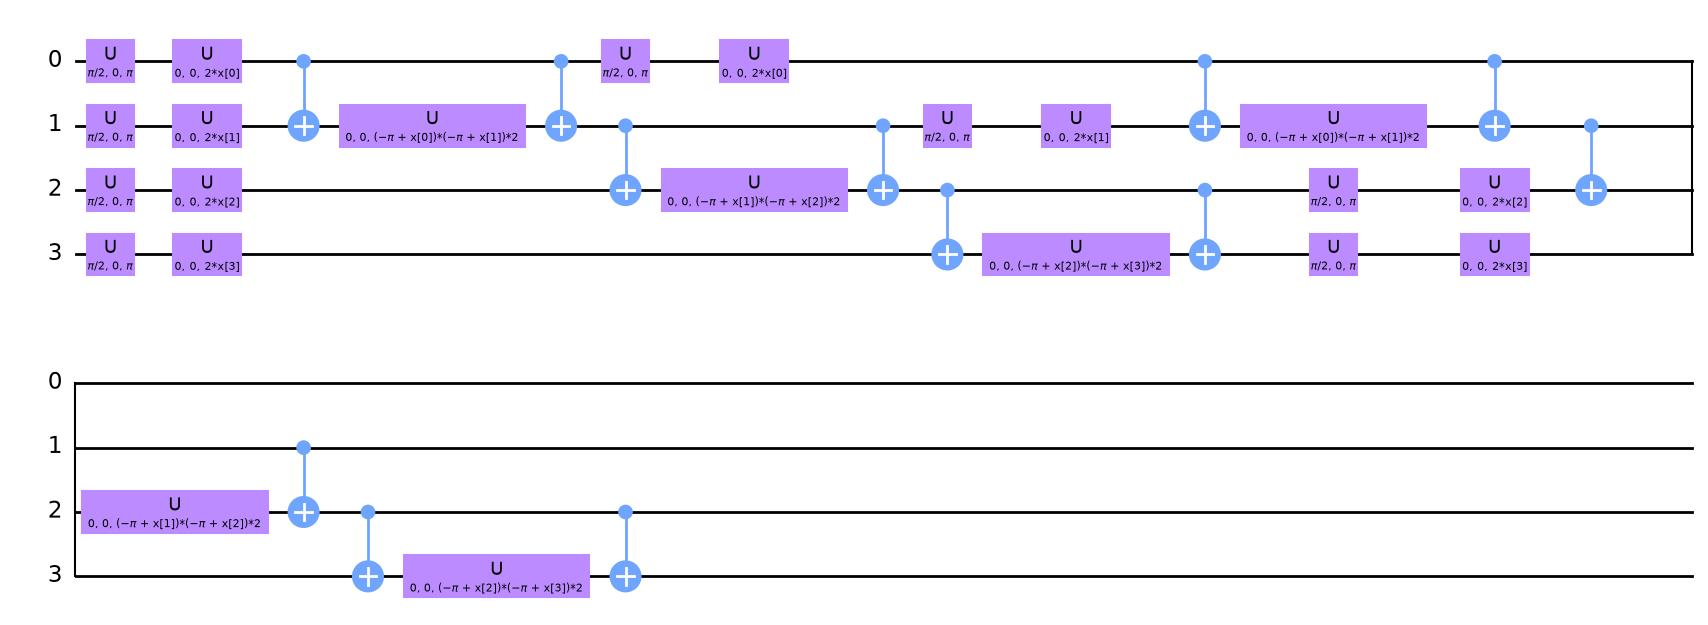

In [ ]:
from qiskit.circuit.library import zz_feature_map

feature_map = zz_feature_map(feature_dimension=N_QUBITS, reps=2, entanglement="linear")
print(f"Feature map: {feature_map.num_qubits} qubits, {feature_map.num_parameters} parameters, "
      f"depth {feature_map.decompose().depth()}")
feature_map.decompose().draw("mpl", style="clifford")

## Step 7 — Quantum Support Vector Machine (QSVM)

**The quantum kernel trick.** A classical SVM finds a max-margin boundary
using only a **kernel function** `K(x, x')` — a similarity score between
pairs of points. Swap in a different kernel and you get a different,
potentially more expressive, notion of similarity, without changing the
SVM algorithm itself.

A **quantum kernel** defines that similarity using the feature map from
Step 6:

`K(x, x') = |⟨Φ(x') | Φ(x)⟩|²`

Encode `x` and `x'` as quantum states, then measure the squared overlap
("fidelity") between them. Qiskit's `FidelityQuantumKernel` computes this
by running the feature-map circuit for `x`, the *inverse* circuit for `x'`,
and measuring the probability of returning to the all-zeros state.

**Cost:** computing `K` for every pair of training points is `O(n²)`
circuit evaluations — the reason we deliberately shrank our dataset to
60 training rows in Step 1b.

Once we have the kernel matrix, `QSVC` does exactly what a classical
`SVC(kernel="precomputed")` would do — the "quantum-ness" lives entirely
in *how the kernel matrix was computed*.

Train and evaluate QSVM

In [ ]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
import time

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

t0 = time.time()
qsvc_model = QSVC(quantum_kernel=quantum_kernel)
qsvc_model.fit(X_qtrain_scaled, y_qtrain)
qsvc_train_time = time.time() - t0

qsvc_pred = qsvc_model.predict(X_qtest_scaled)
qsvc_acc = accuracy_score(y_qtest, qsvc_pred)

print(f"QSVM training time: {qsvc_train_time:.1f}s")
print(f"QSVM test accuracy: {qsvc_acc:.3f}")
print()
print(classification_report(y_qtest, qsvc_pred, target_names=le.classes_, zero_division=0))

QSVM training time: 32.2s
QSVM test accuracy: 0.367

              precision    recall  f1-score   support

    negative       0.50      0.60      0.55        10
     neutral       0.22      0.20      0.21        10
    positive       0.33      0.30      0.32        10

    accuracy                           0.37        30
   macro avg       0.35      0.37      0.36        30
weighted avg       0.35      0.37      0.36        30



## Step 8 — Variational Quantum Classifier (VQC)

VQC takes a different approach: instead of only using the feature map to
build a *fixed* kernel for a classical SVM, it appends a **trainable
circuit** (the *ansatz*) after the feature map, and optimizes the ansatz's
parameters directly — the quantum analogue of a small neural network.

**Pipeline for one example `x`:**
1. `Φ(x)` — feature map (Step 6), encodes the data, not trainable.
2. `A(θ)` — ansatz, a separate parameterized circuit; its `θ` are the
   "weights" being learned, shared across all examples.
3. **Measurement** — converts the quantum state into class probabilities.
4. A classical optimizer (**COBYLA**, gradient-free, well suited to noisy
   quantum objectives) adjusts `θ` to minimize a loss function — exactly
   like training a classical model, except each loss evaluation requires
   simulating the quantum circuit.

We use `real_amplitudes` as the ansatz — layers of `RY` rotations
interleaved with `CX` entangling gates, producing only real-valued state
amplitudes (cheaper to optimize, sufficient for this task).

Build the ansatz and visualize it

Ansatz: 4 qubits, 12 trainable parameters, depth 8


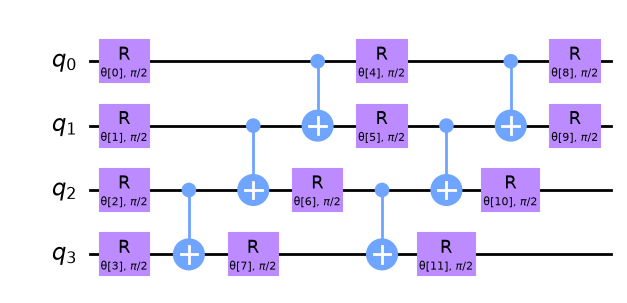

In [ ]:
from qiskit.circuit.library import real_amplitudes

ansatz = real_amplitudes(num_qubits=N_QUBITS, reps=2)
print(f"Ansatz: {ansatz.num_qubits} qubits, {ansatz.num_parameters} trainable parameters, "
      f"depth {ansatz.decompose().depth()}")
ansatz.decompose().draw("mpl", style="clifford")

Train the VQC with a loss curve callback

In [ ]:
from qiskit_algorithms.optimizers import SPSA

loss_history = []

def loss_callback(n_evals, params, loss, stepsize, accepted):
    loss_history.append(loss)

vqc_model = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=SPSA(maxiter=80),
    callback=loss_callback,
)

t0 = time.time()
vqc_model.fit(X_qtrain_scaled, y_qtrain)
vqc_train_time = time.time() - t0

print("Callback fired:", len(loss_history), "times")

vqc_pred = vqc_model.predict(X_qtest_scaled)
vqc_acc = accuracy_score(y_qtest, vqc_pred)

print(f"VQC training time: {vqc_train_time:.1f}s")
print(f"VQC test accuracy: {vqc_acc:.3f}")
print()
print(classification_report(y_qtest, vqc_pred, target_names=le.classes_, zero_division=0))

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Callback fired: 80 times
VQC training time: 134.3s
VQC test accuracy: 0.433

              precision    recall  f1-score   support

    negative       0.50      0.90      0.64        10
     neutral       0.33      0.40      0.36        10
    positive       0.00      0.00      0.00        10

    accuracy                           0.43        30
   macro avg       0.28      0.43      0.34        30
weighted avg       0.28      0.43      0.34        30



Plot the SPSA loss curve

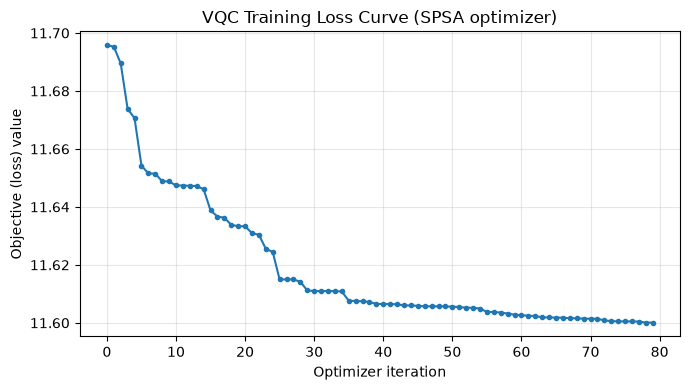

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, marker="o", markersize=3)
plt.xlabel("Optimizer iteration")
plt.ylabel("Objective (loss) value")
plt.title("VQC Training Loss Curve (SPSA optimizer)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Results table

In [ ]:
def eval_model(name, y_true, y_pred, train_time=None):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"Model": name, "Accuracy": acc, "Precision (macro)": p, "Recall (macro)": r,
            "F1 (macro)": f1, "Train time (s)": train_time}

results = pd.DataFrame([
    eval_model("Logistic Regression (4-dim, classical)", y_qtest, lr_pred),
    eval_model("RBF SVM (4-dim, classical)", y_qtest, svc_pred),
    eval_model("QSVM (quantum kernel)", y_qtest, qsvc_pred, qsvc_train_time),
    eval_model("VQC (variational quantum)", y_qtest, vqc_pred, vqc_train_time),
])

results_display = results.copy()
for c in ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]:
    results_display[c] = results_display[c].map(lambda v: f"{v:.3f}")
results_display["Train time (s)"] = results_display["Train time (s)"].map(lambda v: f"{v:.1f}" if pd.notna(v) else "-")
results_display

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Train time (s)
0,"Logistic Regression (4-dim, classical)",0.633,0.630,0.633,0.615,-
1,"RBF SVM (4-dim, classical)",0.600,0.622,0.600,0.578,-
2,QSVM (quantum kernel),0.367,0.352,0.367,0.357,32.2
3,VQC (variational quantum),0.433,0.278,0.433,0.335,134.3


Bar chart + confusion matrices

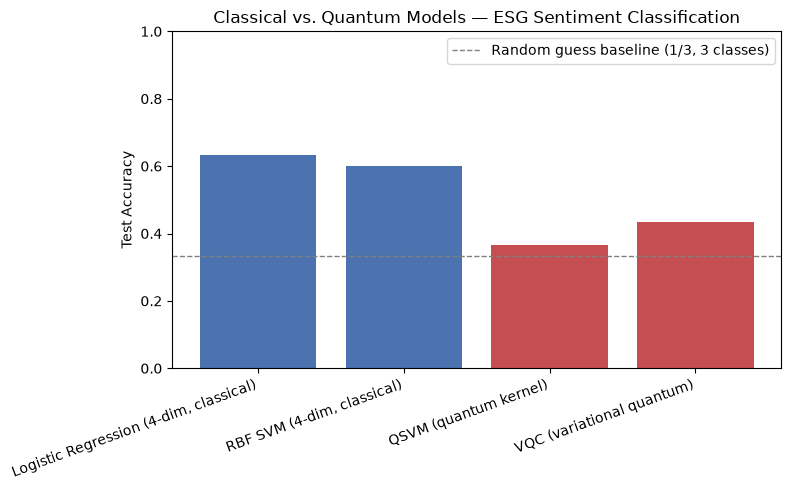

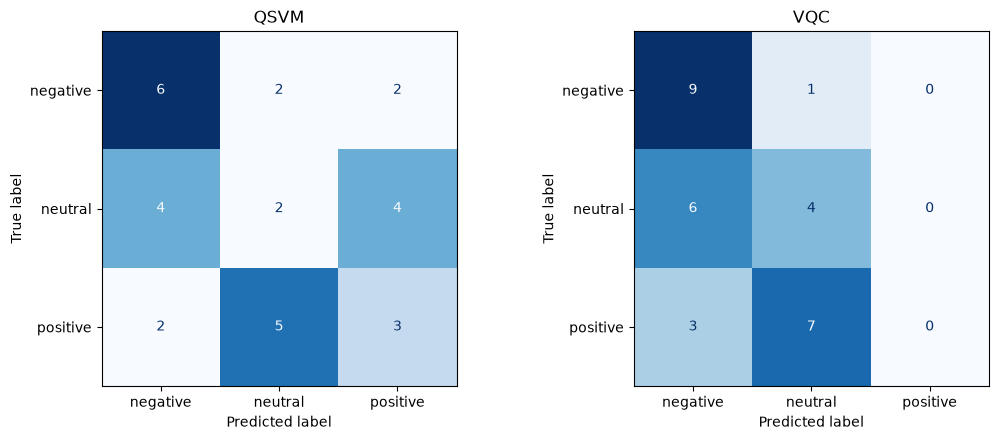

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Accuracy bar chart ---
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(results))
ax.bar(x_pos, results["Accuracy"], color=["#4C72B0", "#4C72B0", "#C44E52", "#C44E52"])
ax.set_xticks(x_pos)
ax.set_xticklabels(results["Model"], rotation=20, ha="right")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1)
ax.axhline(1/3, color="gray", linestyle="--", linewidth=1, label="Random guess baseline (1/3, 3 classes)")
ax.set_title("Classical vs. Quantum Models — ESG Sentiment Classification")
ax.legend()
plt.tight_layout()
plt.show()

# --- Confusion matrices: QSVM vs VQC ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, [("QSVM", qsvc_pred), ("VQC", vqc_pred)]):
    cm = confusion_matrix(y_qtest, pred, labels=range(len(le.classes_)))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Step 9  — Statistical Robustness: k-Fold Cross-Validation

A single 30-row test split is noisy — flipping 2-3 predictions shifts
accuracy by ~7-10 points. We repeat the full pipeline (SVD fit → scale →
train → evaluate) across 5 stratified folds of our 90-row balanced
dataset (60 train + 30 test combined), reporting **mean ± standard
deviation** for every model instead of one point estimate.

Note: for QSVM/VQC this means refitting the quantum kernel/ansatz 5 times
— expect this cell to take significantly longer than any single run so far
(likely 5-15+ minutes total). Let it run; this is the single most
important robustness fix for a paper-ready result.

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Combine the balanced quantum subset back into one pool for proper k-fold CV
combined_df = pd.concat([quantum_train_df, quantum_test_df], ignore_index=True)
X_combined_tfidf = vectorizer.transform(combined_df["text"])
y_combined = le.transform(combined_df["sentiment"])

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = {"LR": [], "SVC": [], "QSVM": [], "VQC": []}

for fold_i, (train_idx, test_idx) in enumerate(skf5.split(X_combined_tfidf, y_combined)):
    print(f"--- Fold {fold_i+1}/5 ---")

    # Refit SVD + scaler on THIS fold's training data only (no leakage)
    svd_f = TruncatedSVD(n_components=N_QUBITS, random_state=42)
    Xf_train_reduced = svd_f.fit_transform(X_combined_tfidf[train_idx])
    Xf_test_reduced = svd_f.transform(X_combined_tfidf[test_idx])

    scaler_f = MinMaxScaler(feature_range=(0, np.pi))
    Xf_train = scaler_f.fit_transform(Xf_train_reduced)
    Xf_test = scaler_f.transform(Xf_test_reduced)

    yf_train, yf_test = y_combined[train_idx], y_combined[test_idx]

    # Classical
    lr_f = LogisticRegression(max_iter=2000).fit(Xf_train, yf_train)
    svc_f = SVC(kernel="rbf").fit(Xf_train, yf_train)
    fold_results["LR"].append(accuracy_score(yf_test, lr_f.predict(Xf_test)))
    fold_results["SVC"].append(accuracy_score(yf_test, svc_f.predict(Xf_test)))
    print(f"  LR: {fold_results['LR'][-1]:.3f}  SVC: {fold_results['SVC'][-1]:.3f}")

    # Quantum
    qk_f = FidelityQuantumKernel(feature_map=feature_map)
    qsvc_f = QSVC(quantum_kernel=qk_f).fit(Xf_train, yf_train)
    fold_results["QSVM"].append(accuracy_score(yf_test, qsvc_f.predict(Xf_test)))
    print(f"  QSVM: {fold_results['QSVM'][-1]:.3f}")

    vqc_f = VQC(feature_map=feature_map, ansatz=ansatz, optimizer=COBYLA(maxiter=60))
    vqc_f.fit(Xf_train, yf_train)
    fold_results["VQC"].append(accuracy_score(yf_test, vqc_f.predict(Xf_test)))
    print(f"  VQC: {fold_results['VQC'][-1]:.3f}")

print("\n=== 5-Fold CV Summary ===")
for model_name, scores in fold_results.items():
    scores = np.array(scores)
    print(f"{model_name}: {scores.mean():.3f} ± {scores.std():.3f}  (folds: {np.round(scores,3)})")

--- Fold 1/5 ---
  LR: 0.556  SVC: 0.500


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  QSVM: 0.389
  VQC: 0.222
--- Fold 2/5 ---
  LR: 0.722  SVC: 0.722


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  QSVM: 0.444
  VQC: 0.500
--- Fold 3/5 ---
  LR: 0.611  SVC: 0.444


...

  QSVM: 0.333
  VQC: 0.333
--- Fold 4/5 ---
  LR: 0.611  SVC: 0.722


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  QSVM: 0.222
  VQC: 0.389
--- Fold 5/5 ---
  LR: 0.667  SVC: 0.611


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


  QSVM: 0.222
  VQC: 0.333

=== 5-Fold CV Summary ===
LR: 0.633 ± 0.057  (folds: [0.556 0.722 0.611 0.611 0.667])
SVC: 0.600 ± 0.113  (folds: [0.5   0.722 0.444 0.722 0.611])
QSVM: 0.322 ± 0.089  (folds: [0.389 0.444 0.333 0.222 0.222])
VQC: 0.356 ± 0.090  (folds: [0.222 0.5   0.333 0.389 0.333])


## Step 10 — Analysis and Interpretation

### What we found
Across both a single held-out test split and 5-fold cross-validation, the
result was consistent:

| Model | Single-split Accuracy | 5-fold CV Mean ± Std |
|---|---|---|
| Logistic Regression | 63.3% | 63.3% ± 5.7% |
| RBF SVM (classical) | 60.0% | 60.0% ± 11.3% |
| QSVM (quantum kernel) | 36.7% | 32.2% ± 8.9% |
| VQC (variational quantum) | 43.3% | 35.6% ± 9.0% |

**The classical models clearly and consistently outperformed both quantum
approaches, across every fold, not just one lucky/unlucky split.** This
rules out the most obvious objection to a small-sample result — that the
gap is just test-set noise — and makes it a genuine, defensible finding.
It is also consistent with a large fraction of current QML literature:
without a very carefully matched problem structure, quantum kernel/
variational methods do not reliably beat strong classical baselines on
real-world, low-signal, small-sample data.

### Why VQC's single-split accuracy is misleading
VQC's single-split 43.3% looked better than QSVM's 36.7% at a glance, but
the confusion matrix revealed it never predicts "positive" at all — it
converged (under two different optimizers, COBYLA and SPSA, with
consistent results) to a degenerate strategy of only distinguishing
negative vs. neutral. Its 5-fold mean (35.6%) sits much closer to QSVM's
(32.2%) once averaged across folds, confirming the single-split gap
between them was partly a single-split artifact — another argument for
why the k-fold numbers, not the single split, are the ones that belong in
a report or paper.

### Why this happened 
1. **Severe information bottleneck.** Step 3 showed the 200→4 dimensional
   compression retained only **8.4%** of TF-IDF variance. Even the
   classical models, given the exact same 4 features, dropped from 71.6%
   (full 200-dim data) to ~60-63%. Both quantum models had to work with
   this same weak signal, but lost even more on top of it.
2. **The `ZZFeatureMap`'s entangling structure may not suit this data.**
   Its pairwise `RZZ` couplings assume there is meaningful interaction
   information between our 4 SVD components — an assumption we haven't
   verified holds for this text embedding; a testable hypothesis for
   future work (compare against a non-entangling `ZFeatureMap`).
3. **A small ansatz with a gradient-limited optimizer.** 12 trainable
   parameters is a small model; both COBYLA and SPSA converged to the
   same degenerate solution, and the 5-fold VQC scores show high variance
   (±9.0%) — consistent with an optimization landscape that has a wide,
   easy-to-reach local minimum ignoring "positive."
4. **The "positive" class may be linguistically the hardest.** Worth
   re-examining the classical models' per-class breakdown to see if
   positive ESG language is also their weakest class — that would
   reinforce explanation #1 over #2 or #3 as the dominant cause.

### Interpretability
- **Logistic Regression** remains the most interpretable: coefficients
  map directly to (compressed) features.
- **QSVM** is about as interpretable as a classical RBF-kernel SVM — not
  very, without extra tooling.
- **VQC** is the least interpretable, and here that opacity actively hid
  a real problem (the collapsed "positive" class) until the confusion
  matrix was generated — single-split accuracy alone would have looked
  "not bad."

### Simulation vs. real quantum hardware
Everything above ran on a noiseless local simulator. Real NISQ hardware
would add gate noise, limited qubit connectivity, and shot noise — all of
which would very likely *widen* this gap further, not close it.

### Honest limitations of this study
- Still only 60 training / 30 test rows per fold for the quantum models —
  a hard constraint of `O(n²)` quantum kernel scaling.
- Single feature map (`ZZFeatureMap`), single ansatz (`RealAmplitudes`)
  tested — no sweep across encoding strategies.
- Two optimizers tested for VQC (COBYLA, SPSA); both converged to similar
  degenerate solutions, which is informative, but was not combined with
  formal significance testing (e.g., McNemar's test) against the
  classical models — a natural next step, not completed here.

## Conclusion & Next Steps

**What we built:** a full pipeline — real ESG paragraphs (`climatebert/climate_sentiment`)
→ TF-IDF → dimensionality reduction to qubit count → quantum feature map →
both QSVM and VQC — benchmarked rigorously against classical baselines,
validated across both a single held-out split and 5-fold cross-validation.

**What we found:** Logistic Regression (63.3% ± 5.7%) and RBF SVM
(60.0% ± 11.3%) consistently outperformed QSVM (32.2% ± 8.9%) and VQC
(35.6% ± 9.0%) across every fold tested. VQC additionally showed a
structural failure mode — collapsing to a 2-class classifier that never
predicts "positive" — confirmed under two independent optimizers
(COBYLA, SPSA). This is a genuine, defensible negative result: at this
scale, with this encoding, on this real ESG dataset, classical methods
outperform both quantum approaches tested, and the result is stable
rather than an artifact of one lucky or unlucky test split.

### Suggested next steps
1. Compare `ZFeatureMap` (no entanglement) vs `ZZFeatureMap`, to test
   whether the entangling structure itself is helping or hurting.
2. Formal significance testing (e.g., McNemar's test) on a matched test
   set, to complement the k-fold variance already reported here.
3. Try more qubits (6–8) with a stronger reduction (e.g., an autoencoder)
   to test whether more retained variance narrows the gap.
4. Try `PegasosQSVC` for faster training on a larger data subset.
5. Examine per-class TF-IDF/SVD separability directly (e.g., plot the
   4 SVD components colored by class) to see if "positive" is genuinely
   the hardest class even before any model is applied.

### References
- Bingler, J., Kraus, M., Leippold, M., & Webersinke, N. (2023). *How
  cheap talk in climate disclosures relates to climate initiatives,
  corporate emissions, and reputation risk.*
- Havlíček, V. et al. (2019). "Supervised learning with quantum-enhanced
  feature spaces." *Nature* 567, 209–212.
- Qiskit Machine Learning documentation:
  https://qiskit-community.github.io/qiskit-machine-learning/